# Notebook Description

Purpose of this notebook is to compare Machine Learning Models implemented in ML_baselines.py with in-depth analysis to detect the best performing baseline model.

Workflow:
1. Use report_binary.md report generated by running the ML_baselines.py script to detect setting resulting in the best F1 score (weighted) for each of the implemented models:
    - Naive Bayas
    - Support Vector Machine (SVM)
    - Logistic Regression (BoW)
    - Logistic Regression (TFIDF)
2. Retrain each of the models on full training data (include both data.csv and train.csv) + Create predictions using test set
3. Evaluate performance of each of the models on test set and compare the results

# Load packages

In [13]:
from pathlib import Path
import pandas as pd
import re
from io import StringIO
import matplotlib.pyplot as plt
from scripts.ML_baselines import encode_target, preprocess_text, extract_features
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import ast
import time
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score


# Data Loading

In [14]:
# training set
df_train = pd.read_csv("../data/splits/train.csv")
df_val = pd.read_csv("../data/splits/val.csv")
df_full_train = pd.concat([df_train, df_val], ignore_index=True)
# test set
df_test = pd.read_csv("../data/splits/test.csv")
# select relevant columns
df_full_train = df_full_train[["sentence", "word_order", "language", "period"]]
df_test = df_test[["sentence", "word_order", "language", "period"]]

Note: while only variables "sentence" and "word_order" will be used for model training ("sentence" being a feature and "word_order" being a target variable), we have included additional 2 columns (language, period) for more in detail analysis of performance (e.g. to explore if model performs different across different languages).

# 1. Retrieve best performing model (F1 weighted score) on CV by reading report file

In [15]:
# path to report file
report_path = Path("../reports/report_binary.md")
# read report content
text = report_path.read_text()
# extract validation results table using regex
pattern = r"## VALIDATION RESULTS\n\n(.*?)\n\n---"
match = re.search(pattern, text, re.S)
table_md = match.group(1)
# load table into DataFrame
df_CV_results = pd.read_csv(
    StringIO(table_md),
    sep="|",
    engine="python",
    skiprows=[1] 
).dropna(axis=1, how="all")
# clean column names
df_CV_results.columns = df_CV_results.columns.str.strip()
# clean values in DataFrame
df_CV_results = df_CV_results.map(lambda x: x.strip() if isinstance(x, str) else x)
# remove columns that are not needed
df_CV_results = df_CV_results[["feature", "model", "best_params"]]
# convert string representation of dict back to dict
df_CV_results["best_params"] = df_CV_results["best_params"].apply(ast.literal_eval)
# display the DataFrame
df_CV_results


,feature,model,best_params
0,BoW,LogisticRegression,"{'C': 1.0, 'penalty': 'l2', 'solver': 'saga'}"
1,TFIDF,LogisticRegression,"{'C': 5.0, 'penalty': 'l2', 'solver': 'saga'}"
2,TFIDF,SVM,{'C': 1.0}
3,BoW,NaiveBayes,{'alpha': 2.0}


# 2. Retraining the models + predict the target variable

## 2.1 Preprocessing

In [16]:
# preprocess sentences
X_full_train = df_full_train["sentence"].apply(preprocess_text)
X_test = df_test["sentence"].apply(preprocess_text)
# encode target labels
y_full_train = encode_target(df_full_train, "word_order")
y_test = encode_target(df_test, "word_order")

In [17]:
X_full_train.head()

0    die berliner afd trifft sich nicht an diesem w...
1    da jede investition in berlin aber steuern gen...
2    this is just another sign that people are not ...
3    лучше держаться подальше от озера или речки ка...
4    ein hütchen mit federn die armbrust über der s...
Name: sentence, dtype: object

In [18]:
y_full_train.head()

0    1
1    0
2    0
3    0
4    0
Name: word_order, dtype: int64

## 2.2 Training the models on full training set (combined train.csv and val.csv) + predict target variable on test set (test.csv)

In [19]:
# helper function to get model instance
def get_model(model_name: str, params: dict):
    if model_name == "LogisticRegression":
        return LogisticRegression(**params, max_iter=1000)
    elif model_name == "SVM":
        return LinearSVC(**params)
    elif model_name == "NaiveBayes":
        return MultinomialNB(**params)

In [20]:
predictions = {}
training_times = {}

for row in df_CV_results.itertuples(index=False):

    feature = row.feature.lower()
    model_name = row.model
    params = row.best_params

    key = f"{model_name}_{feature}"

    print(f"\nTraining model: {model_name}")
    print(f"Feature extraction method: {feature}")
    print(f"Parameters: {params}")

    # Extract features
    X_train_vec, X_test_vec = extract_features(
        X_full_train,
        X_test,
        method=feature
    )

    # Build model
    model = get_model(model_name, params)

    # Train model on full training data
    start = time.time()
    model.fit(X_train_vec, y_full_train)
    training_times[key] = round(time.time() - start, 3)

    print(f"Training time: {training_times[key]} seconds")

    # Predict target variable
    y_pred = model.predict(X_test_vec)

    # Save results
    predictions[key] = y_pred



Training model: LogisticRegression
Feature extraction method: bow
Parameters: {'C': 1.0, 'penalty': 'l2', 'solver': 'saga'}
Training time: 35.859 seconds

Training model: LogisticRegression
Feature extraction method: tfidf
Parameters: {'C': 5.0, 'penalty': 'l2', 'solver': 'saga'}
Training time: 4.585 seconds

Training model: SVM
Feature extraction method: tfidf
Parameters: {'C': 1.0}
Training time: 1.779 seconds

Training model: NaiveBayes
Feature extraction method: bow
Parameters: {'alpha': 2.0}
Training time: 0.043 seconds


# 3. Performance evaluation

## 3.1 Confusion matrix

In [21]:
# Compute and store confusion matrices
conf_matrices = {}
for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    conf_matrices[name] = cm

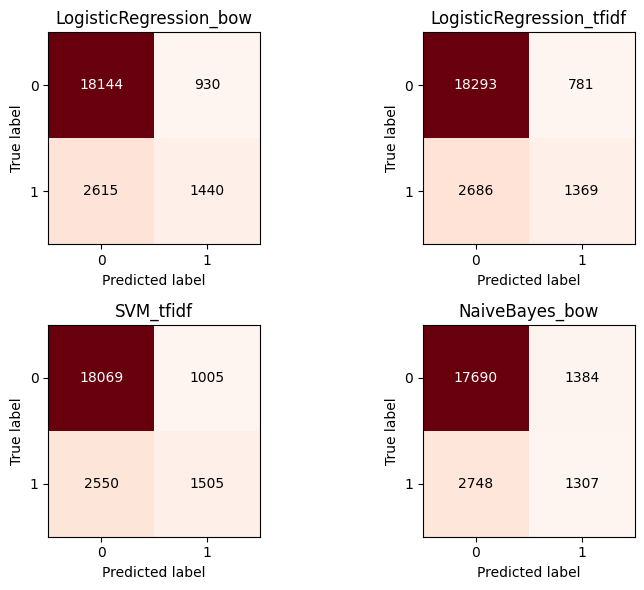

In [22]:
# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.ravel()

for ax, (name, y_pred) in zip(axes, predictions.items()):

    cm = confusion_matrix(y_test, y_pred)

    im = ax.imshow(cm, cmap="Reds")

    ax.set_title(f"{name}")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])

    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, cm[i, j],
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black"
            )

plt.tight_layout()
plt.show()

Based on the confusion matrices, we draw the following conclusions:

1. All models exhibit broadly similar behavior and error patterns.
2. The dataset is strongly imbalanced, with non-SVO sentences dominating the corpus.
3. The positive class (SVO) shows substantially lower recall, while the negative class achieves high specificity.
4. Logistic Regression with TF-IDF results in the lowest number of false positives, making it the best model for identifying non-SVO sentences.
5. SVM with TF-IDF yields the lowest number of false negatives, making it the most effective model for detecting SVO sentences.

### Model Comparison Summary

- Naive Bayes performs worst across both classes and is therefore excluded from further consideration.
- Logistic Regression (TF-IDF) is best for negative-class discrimination.
- SVM (TF-IDF) is best for positive-class detection.
- Logistic Regression (BoW) provides balanced but not best-in-class performance.

**Final model selection depends on whether minimizing false positives or false negatives is more important for the task. Alternatively, to avoid prioritizing a single class, Logistic Regression with BoW can be selected 
as a balanced model that offers competitive performance across both classes.**

Before making final decision, lets compute additional metrics for quantitatice comparison.

## 3.2 Quantitative Analysis

In [23]:
metrics = []

for name, y_pred in predictions.items():

    metrics.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
    })

df_metrics = pd.DataFrame(metrics).set_index("model").round(4)
df_metrics


,accuracy,balanced_accuracy,f1_weighted,f1_macro,precision_macro,recall_macro
model,,,,,,
LogisticRegression_bow,0.8467,0.6532,0.8299,0.6796,0.7408,0.6532
LogisticRegression_tfidf,0.8501,0.6483,0.8307,0.6773,0.7544,0.6483
SVM_tfidf,0.8463,0.6592,0.8312,0.6845,0.7380,0.6592
NaiveBayes_bow,0.8213,0.6249,0.8064,0.6415,0.6756,0.6249


Again, we observe that Naive Bayes consistently performs worst across all metrics and is therefore excluded.

Given the strong class imbalance and the fact that both word orders are linguistically meaningful, balanced accuracy is selected as the primary evaluation criterion to ensure fair treatment of both classes.

Based on **balanced accuracy**, Support Vector Machine with TF-IDF is selected as the final baseline model. In addition, this model also achieves the highest recall for the SVO class, which further supports the
decision, as failing to identify SVO sentences is considered a more severe error than a false positive classification.

Therefore, **SVM with TF-IDF** is selected as the baseline model both for its balanced performance and its superior detection of SVO constructions.